### Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib
from sklearn.model_selection import train_test_split , StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score, classification_report


c:\Users\hp\Desktop\Data Science & Analytics (LuxDevHQ)\AUGUST\week23ML_project\titanic-survival-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



### Load the Dataset

In [2]:
titanic_df = pd.read_csv("../data/train.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 1: Basic Data Checks

In [3]:
def basic_checks(data):
    print("-"*35, "Duplicates","-"*35)
    print(data.duplicated().sum())
    print("-"*35, "Shape", "-"*35)
    print(data.shape)
    print("-"*35, "Missing Values", "-"*35)
    print(data.isna().sum())
    print("-"*35, "Data Types", "-"*35)
    print(data.dtypes)
    print("-"*35, "Summary Statistics (Numerical)", "-"*35)
    print(display(data.describe().T))
    print("-"*35, "Summary Statistics Categorical Data", "-"*35)
    print(display(data.describe(include = ["str","object"]).T))


In [4]:
basic_checks(titanic_df)

----------------------------------- Duplicates -----------------------------------
0
----------------------------------- Shape -----------------------------------
(891, 12)
----------------------------------- Missing Values -----------------------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------------------------------- Data Types -----------------------------------
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
----------------------------------- Summary Statistics (Numerical) -----------------------------------


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


None
----------------------------------- Summary Statistics Categorical Data -----------------------------------


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


None


#### Checking Unique Entries in Categorical Columns

In [5]:
categorical_cols = ["Pclass", "Sex", "Embarked"]

for col in categorical_cols:
    print("-"*35, col,"-"*35)
    print(titanic_df[col].unique())
    


----------------------------------- Pclass -----------------------------------
[3 1 2]
----------------------------------- Sex -----------------------------------
<StringArray>
['male', 'female']
Length: 2, dtype: str
----------------------------------- Embarked -----------------------------------
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


__Percentage of missing values__

In [6]:
(titanic_df.isnull().sum() / len(titanic_df)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

__Dropping the Cabin Column__

In [7]:
titanic_df = titanic_df.drop(columns =["Cabin"])

In [8]:
titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

### Step 2: Distribution of the Target Column

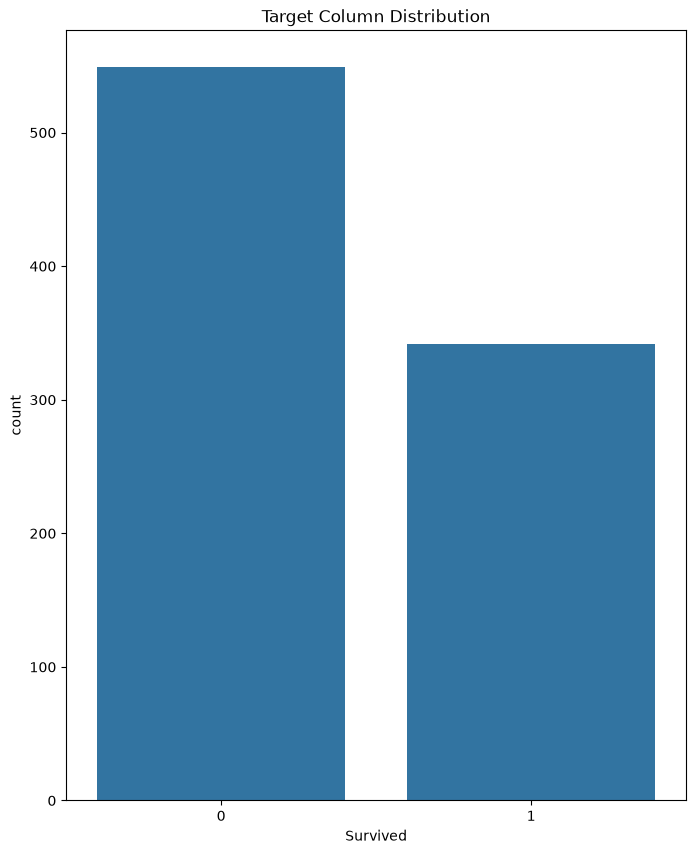

In [9]:
plt.figure(figsize=(8,10))

sns.countplot(titanic_df, x = "Survived")
plt.xlabel("Survived")
plt.title("Target Column Distribution")

plt.show()


### Step 3: Splitting the target and the features

In [10]:
X = titanic_df.drop(columns = ["PassengerId", "Name", "Ticket", "Survived"])
y = titanic_df["Survived"]

In [11]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='str')

__Separating Numerical and Categorical Columns__

In [12]:
numerical_columns = ["Age", "SibSp", "Parch", "Fare"]
categorical_columns = ["Pclass", "Sex", "Embarked"]

### Splitting into Training and Test Datasets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify = y)

### Step 4: Creating Pipelines

In [14]:
numerical_pipeline = Pipeline(steps= [
                                    ("imputer", SimpleImputer(strategy="median")),
                                    ("scaler", StandardScaler())])

categorical_pipeline = Pipeline(steps= [
                                    ("imputer", SimpleImputer(strategy= "most_frequent")),
                                    ("encoder", OneHotEncoder(handle_unknown= "ignore"))])

__Combining both Preprocessing__

In [15]:
preprocessor = ColumnTransformer(transformers=[
                                                ("num", numerical_pipeline, numerical_columns),
                                                ("cat", categorical_pipeline, categorical_columns)
])

### Step 5: Defining Models to be Used

In [16]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "kneighbours" : KNeighborsClassifier(n_neighbors= 7, metric= "euclidean"),
    "random_forest" : RandomForestClassifier(n_estimators=300, max_depth=15),
    "svm" : SVC(kernel= "rbf", random_state= 42, probability=True),
    "gradient_boosting" : GradientBoostingClassifier(n_estimators=300, max_depth=15)

}

### Step 6: Define Cross Validation

In [17]:
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

results = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
                                ("preprocessor", preprocessor),
                                ("model", model)
    ])

    cv_scores = cross_val_score(pipeline,X_train, y_train, cv = cv, scoring="f1", n_jobs= -1)

    results[model_name] = {"mean_cv_f1": cv_scores.mean(), 
                           "std_cv_f1": cv_scores.std()
                           }

    print(f"{model_name}")
    print(f"f1_scores {cv_scores}")



logistic_regression
f1_scores [0.73394495 0.70707071 0.74285714 0.7047619  0.76190476]
kneighbours
f1_scores [0.73584906 0.70588235 0.75510204 0.69158879 0.70833333]
random_forest
f1_scores [0.75229358 0.68571429 0.77358491 0.71428571 0.74747475]
svm
f1_scores [0.78504673 0.7254902  0.78       0.71698113 0.71578947]
gradient_boosting
f1_scores [0.7047619  0.65384615 0.69811321 0.75213675 0.71428571]


In [18]:
results_df = pd.DataFrame(results).T
results_df.head()

,mean_cv_f1,std_cv_f1
logistic_regression,0.730108,0.021732
kneighbours,0.719351,0.022908
random_forest,0.734671,0.030987
svm,0.744662,0.031136
gradient_boosting,0.704629,0.031533


logistic_regression
roc_auc_scores [0.85630165 0.82345041 0.87722048 0.83322811 0.87584175]
kneighbours
roc_auc_scores [0.82272727 0.8464876  0.9031348  0.82817761 0.84090909]
random_forest
roc_auc_scores [0.8463843  0.85692149 0.88192268 0.87236953 0.86752946]
svm
roc_auc_scores [0.85630165 0.81105372 0.90125392 0.84774832 0.83922559]


c:\Users\hp\Desktop\Data Science & Analytics (LuxDevHQ)\AUGUST\week23ML_project\titanic-survival-prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


gradient_boosting
roc_auc_scores [0.84163223 0.82716942 0.84346917 0.87058081 0.86237374]


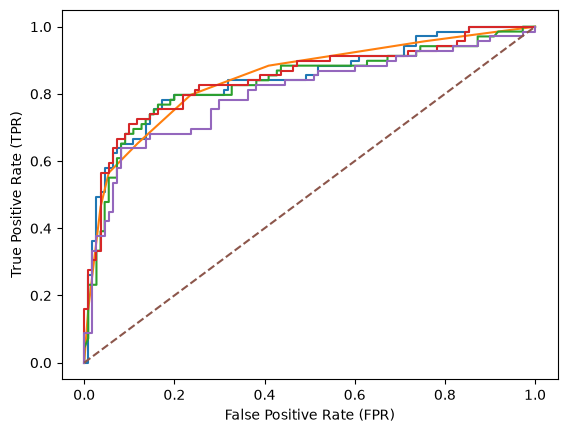

In [19]:
for model_name, model in models.items():
    pipeline = Pipeline(steps=[
                                ("preprocessor", preprocessor),
                                ("model", model)
    ])

    cv_scores = cross_val_score(pipeline,X_train, y_train, cv = cv, scoring="roc_auc", n_jobs= -1)

    results[model_name] = {"mean_cv_roc_auc": cv_scores.mean(), 
                           "std_cv_roc_auc": cv_scores.std()
                           }

    print(f"{model_name}")
    print(f"roc_auc_scores {cv_scores}")

    pipeline.fit(X_train, y_train)
    # Get the probability of the positive class (Survived = 1)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    # Calculate the roc_auc_score (auc = area under curve)
    auc_score = roc_auc_score(y_test, y_prob)

    # Calculate the point for roc_curve
    fpr, tpr, threshold = roc_curve(y_test, y_prob)

    # Plotting the models roc_curve
    plt.plot(fpr, tpr, label = f"{model_name}(auc = {auc_score})")

plt.plot([0,1], ls = "--", label = "RandomForestClassifier auc = 0.50")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")

plt.show()



### Step 7: Hyperparameter Setting

Choosing the best configuration settings e.g. max_steps, n_estimators, entropy etc.

_Types_

1. Grid search cv 
2. Randomized search cv
3. Optuna - Uses Bayes Theory, Bayesian optimization


_Hyperparameters used in RandomForest_

- n_estimators
- max_step
- minimum_samples_split
- minimum_samples_leaf


__1. Grid Search CV__

Evaluates every hyperparameter combination that you will give it.

```python
grid_params = {
                "model_n_estimators" : [100,200,300],
                "model_max_depth" : [None, 5, 10],
                "model_min_samples_split" : [2, 5],
                "model_min_samples_leaf" : [1, 2]
}
```
_Disadvantages_

- Curse of dimensionality - as you add more hyperparameters, the number of combinations increases exponentially making the search very slow and expansive.
- Blind and inefficient. Tests every single combination, regardless of whether it works well, wasting time on poor or redundant configurations.
- Discrete limitations. Checks specific predefined values meaning it can easily miss the optimal value between if it falls between 2 grid points.


In [20]:
# Grid Search CV
grid_params = {
                "model__n_estimators" : [100,200,300],
                "model__max_depth" : [None, 5, 10],
                "model__min_samples_split" : [2, 5],
                "model__min_samples_leaf" : [1, 2] 
                }

total_grid_combinations = np.prod([len(values) for values in grid_params.values()])

print("Parameter Combinations", total_grid_combinations)

Parameter Combinations 36


In [21]:
rf_pipeline = Pipeline(steps=[
                                ("preprocessor", preprocessor),
                                ("model", RandomForestClassifier())
])

grid_search = GridSearchCV( estimator= rf_pipeline, param_grid= grid_params, scoring= "f1", cv = cv)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionch

In [22]:
print("Best Grid Search f1 score: ", grid_search.best_score_)
print("Best Parameters: "), grid_search.best_params_

Best Grid Search f1 score:  0.7597968107760981
Best Parameters: 


(None,
 {'model__max_depth': 10,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 5,
  'model__n_estimators': 100})

__2. Randomized Search CV__

Tool to optimize ML hyperparameters by randomly sampling a fixed number of parameter combinations from specified distribution.

Instead of testing every single combination like grid search, it evaluates a random subset determined by the n_iter parameter.

*Advantages*
- More efficient and much faster than grid search cv
- When dealing with large such spaces or many hyperparameters.

*Disadvantages*
- No guarantee that your model will improve. It may miss the best hyperparameter optimization.
- Redundant sampling, where random selection can repeatedly sample highly similar or identical parameter clusters.

In [23]:
random_params = {
                "model__n_estimators" : [100, 200, 300, 400, 500, 600],
                "model__max_depth" : [None, 4, 5, 6, 7, 10],
                "model__min_samples_split" : [2, 3, 4, 5],
                "model__min_samples_leaf" : [1, 2, 3, 4] 
}

random_search = RandomizedSearchCV(estimator=rf_pipeline,
                                   param_distributions= random_params,
                                   n_iter= 30,
                                   scoring= "f1",
                                   cv = cv,
                                   random_state= 42)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 4, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 3, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dir

In [24]:
print("Best Randomized Search CV f1 score: ", random_search.best_score_)
print("Best Parameters: ", random_search.best_params_)

Best Randomized Search CV f1 score:  0.7475693430209638
Best Parameters:  {'model__n_estimators': 200, 'model__min_samples_split': 3, 'model__min_samples_leaf': 3, 'model__max_depth': None}


__3. Optuna - Bayesian Optimization__

In [25]:
def objective(trial):
    params = {"n_estimators" : trial.suggest_int("n_estimators", 100, 1000),
              "max_depth" : trial.suggest_int("max_depth", 3, 30),
              "min_samples_split" : trial.suggest_int("min_samples_split", 2, 20),
              "min_samples_leaf" : trial.suggest_int("min_samples_leaf", 1, 20)
              }
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    pipeline = Pipeline(steps=[
                                ("preprocessor", preprocessor),
                                ("model", rf)
    ])
    score = cross_val_score(pipeline, X_train, y_train, cv = 5, scoring= "f1")

    return score.mean()

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 50)

[I 2026-08-27 12:43:49,990] A new study created in memory with name: no-name-8cb6a7c8-af37-4205-9a2a-2cedcf28c41f
[I 2026-08-27 12:44:00,232] Trial 0 finished with value: 0.7212324051597353 and parameters: {'n_estimators': 946, 'max_depth': 27, 'min_samples_split': 10, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.7212324051597353.
[I 2026-08-27 12:44:07,166] Trial 1 finished with value: 0.7131848611834334 and parameters: {'n_estimators': 615, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 17}. Best is trial 0 with value: 0.7212324051597353.
[I 2026-08-27 12:44:09,643] Trial 2 finished with value: 0.743969244334161 and parameters: {'n_estimators': 230, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.743969244334161.
[I 2026-08-27 12:44:18,210] Trial 3 finished with value: 0.7082439144403737 and parameters: {'n_estimators': 972, 'max_depth': 13, 'min_samples_split': 17, 'min_samples_leaf': 20}. Best is trial 2 with va

In [26]:
study.best_params

{'n_estimators': 292,
 'max_depth': 19,
 'min_samples_split': 7,
 'min_samples_leaf': 2}

In [27]:
study.best_value

0.757822060015911

### Step 8: Training the Final Model

In [28]:
rf_pipeline = Pipeline(steps = [
                                ("preprocessor", preprocessor),
                                ("model", RandomForestClassifier(n_estimators= 501, max_depth=16,
                                                                 min_samples_split=6,
                                                                 min_samples_leaf=1))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Sex','Age',...,'Parch','Fare','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns tha

### Step 9: Evaluating the Model

In [29]:
y_pred = rf_pipeline.predict(X_test)

In [30]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



### Step 10: Save the model

In [31]:
# Saving the model

joblib.dump(rf_pipeline, "../Models/titanic_model.joblib")

['../Models/titanic_model.joblib']

### Step 11: Making Predictions

In [32]:
model = joblib.load('../Models/titanic_model.joblib')

In [33]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [34]:
new_passenger = pd.DataFrame(
                            {
                                'Pclass' : [1],
                                'SibSp' : [2],
                                'Sex' : ['female'],
                                'Age' : [12],
                                'Parch' : [1],
                                'Fare' : [54.7200],
                                'Embarked' : ['S']
                            }
)

new_passenger

,Pclass,SibSp,Sex,Age,Parch,Fare,Embarked
0,1,2,female,12,1,54.72,S


In [35]:
model.predict(new_passenger)

array([1])

In [36]:
model.predict_proba(new_passenger)[:, 1]

array([0.93994313])